In [2]:
pip install numpy==1.24.3


     --------------------------------------- 14.8/14.8 MB 93.2 kB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\chand\\anaconda3\\New folder\\New folder\\python\\Lib\\site-packages\\~-mpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll'
Consider using the `--user` option or check the permissions.



C:\Users\chand\anaconda3\New folder\New folder\python\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loading Kickstarter dataset...
Loaded 378661 records
Columns: ['ID', 'name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'pledged', 'state', 'backers', 'country', 'usd pledged', 'usd_pledged_real', 'usd_goal_real']

Handling missing values...
Missing values per column:
name              4
usd pledged    3797
dtype: int64
Records after cleaning: 378657

Creating success label...
Success rate: 40.39%
Successful: 133956, Failed: 197716

Extracting datetime features...
Created: campaign_duration_days, launch_year, launch_month, launch_day_of_week

Calculating derived features...
Created: funding_ratio, avg_pledge_per_backer, goal_category

Cleaning text fields...
Created: name_clean, name_length, name_word_count, blurb features

Encoding categorical features...
Created: country_grouped, main_category

Removing outliers...
Removed 230 outlier records (0.07%)

Selecting final features...
Selected 20 features

Saving preprocessed data to C:/Users/chand/OneDrive/De

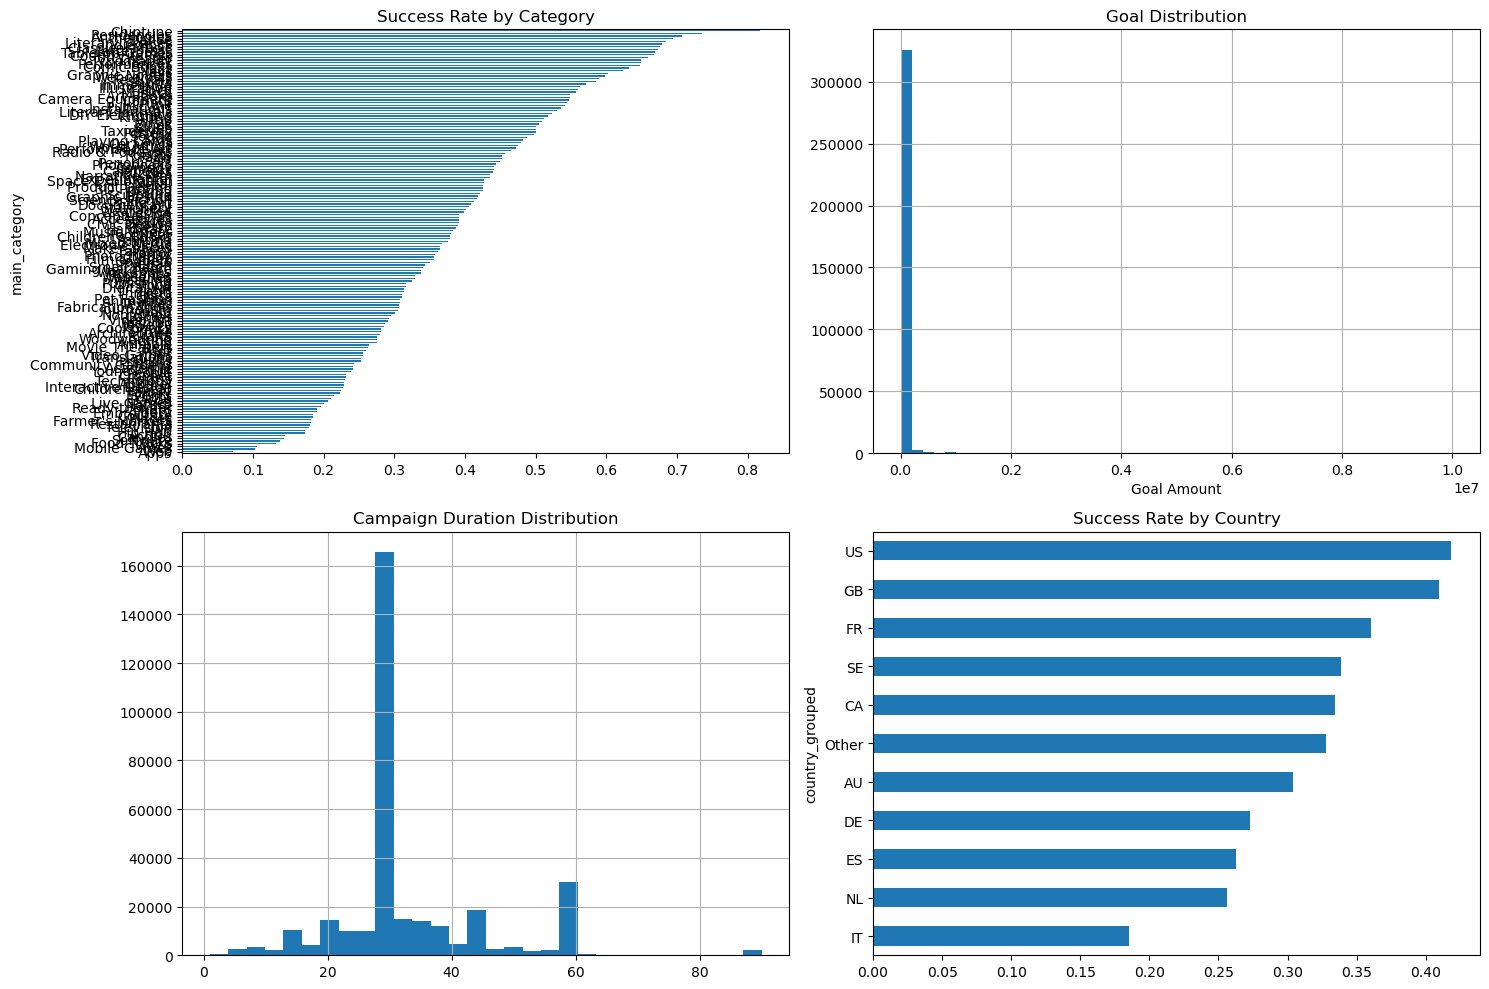

In [1]:
import sys
sys.path.append('../src')

from preprocessing.kickstarter_preprocessor import KickstarterPreprocessor

# Initialize and run
preprocessor = KickstarterPreprocessor('C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/raw/kickstarter_projects.csv')
df = preprocessor.run_full_pipeline('C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/processed/kickstarter_processed.csv')

# Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Success rate by category
df.groupby('main_category')['success'].mean().sort_values().plot(kind='barh', ax=axes[0,0])
axes[0,0].set_title('Success Rate by Category')

# Goal distribution
df['goal'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Goal Distribution')
axes[0,1].set_xlabel('Goal Amount')

# Campaign duration
df['campaign_duration_days'].hist(bins=30, ax=axes[1,0])
axes[1,0].set_title('Campaign Duration Distribution')

# Success by country
df.groupby('country_grouped')['success'].mean().sort_values().plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Success Rate by Country')

plt.tight_layout()
plt.savefig('../data/processed/kickstarter_eda.png')
plt.show()
